In [21]:
import pickle
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load results
# --------------------------------------------------
with open("results.pkl", "rb") as f:
    results = pickle.load(f)

det = results["forecast"]  # deterministic log-returns

q = results["quantile"]["logret_forecasts"]
q01 = q["q01"]
q05 = q["q05"]
q09 = q["q09"]


/home/isc-den/software/mniconda3/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


/home/isc-den/software/mniconda3/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


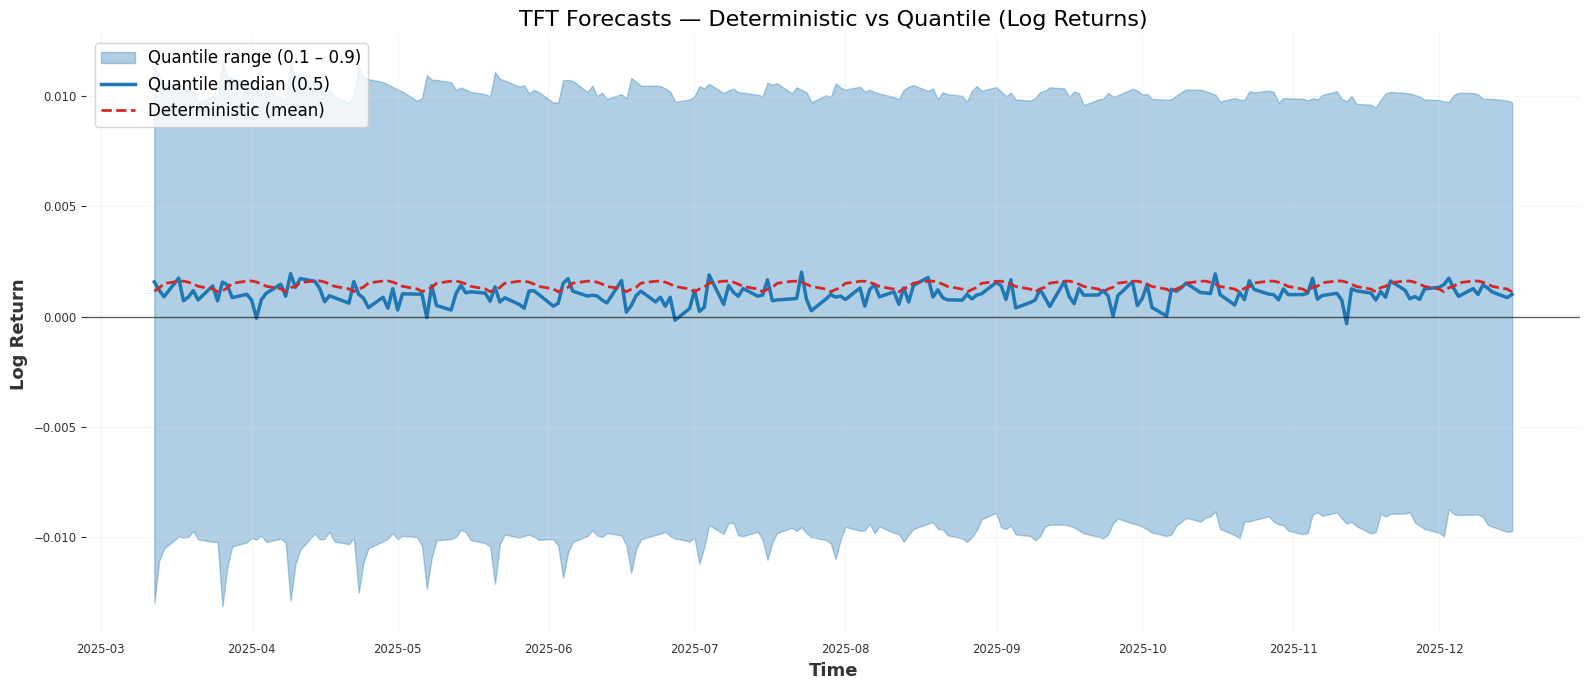

In [10]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Load results
# --------------------------------------------------
with open("results.pkl", "rb") as f:
    results = pickle.load(f)

# --------------------------------------------------
# Extract LOG-RETURN forecasts (already inverse-scaled)
# --------------------------------------------------
det = results["forecast"]  # deterministic mean (log-returns)

q = results["quantile"]["logret_forecasts"]
q01 = q["q01"]  # 0.1
q05 = q["q05"]  # 0.5 (median)
q09 = q["q09"]  # 0.9

# --------------------------------------------------
# Convert to numpy (safe + explicit)
# --------------------------------------------------
x = q05.time_index

det_y = det.values().squeeze()
q01_y = q01.values().squeeze()
q05_y = q05.values().squeeze()
q09_y = q09.values().squeeze()

# --------------------------------------------------
# Plot ONLY last N points (CRITICAL)
# --------------------------------------------------
N = 300   # adjust: 200–500 recommended

x = x[-N:]
det_y = det_y[-N:]
q01_y = q01_y[-N:]
q05_y = q05_y[-N:]
q09_y = q09_y[-N:]

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(16, 7))

# 🔵 Quantile range (0.1–0.9)
plt.fill_between(
    x,
    q01_y,
    q09_y,
    color="tab:blue",
    alpha=0.35,
    label="Quantile range (0.1 – 0.9)",
    zorder=1,
)

# 🔷 Quantile median (0.5)
plt.plot(
    x,
    q05_y,
    color="tab:blue",
    linewidth=2.5,
    label="Quantile median (0.5)",
    zorder=2,
)

# 🔴 Deterministic mean
plt.plot(
    x,
    det_y,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label="Deterministic (mean)",
    zorder=3,
)

# Zero line (important for log-returns)
plt.axhline(0, color="black", linewidth=1, alpha=0.6)

plt.title("TFT Forecasts — Deterministic vs Quantile (Log Returns)", fontsize=16)
plt.xlabel("Time", fontsize=13)
plt.ylabel("Log Return", fontsize=13)

plt.legend(loc="upper left", fontsize=12, frameon=True)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


q01 stats: -0.013141932311063078 -0.009910971019175931 -0.008715066044656081
q05 stats: -0.0003215000049715515 0.0009881291638977618 0.002009838779914672
q09 stats: 0.00947167974547477 0.01019823041307879 0.011557032947594702

Quantile spread stats:
min: 0.018448165247663705
mean: 0.020109201432254725
max: 0.02469896525865778


/home/isc-den/software/mniconda3/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


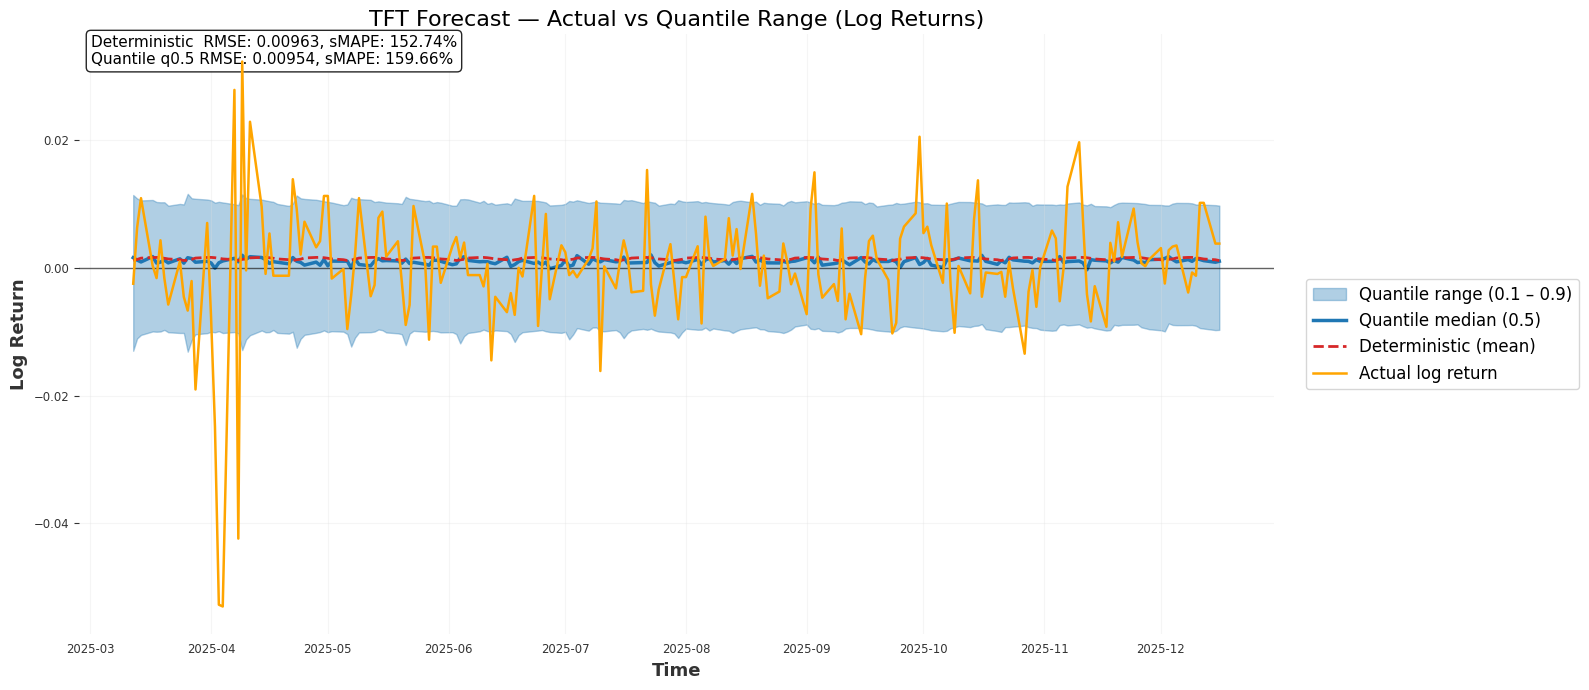

In [24]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Load results
# --------------------------------------------------
with open("results.pkl", "rb") as f:
    results = pickle.load(f)

# --------------------------------------------------
# Extract log-return series
# --------------------------------------------------
actual = results["y_test"]          # ACTUAL log-returns
det = results["forecast"]           # deterministic mean forecast

q = results["quantile"]["logret_forecasts"]
q01 = q["q01"]                      # 0.1
q05 = q["q05"]                      # 0.5 (median)
q09 = q["q09"]                      # 0.9

print("q01 stats:", q01_y.min(), q01_y.mean(), q01_y.max())
print("q05 stats:", q05_y.min(), q05_y.mean(), q05_y.max())
print("q09 stats:", q09_y.min(), q09_y.mean(), q09_y.max())

spread = q09_y - q01_y

print("\nQuantile spread stats:")
print("min:", spread.min())
print("mean:", spread.mean())
print("max:", spread.max())

# --------------------------------------------------
# Convert to numpy
# --------------------------------------------------
x = q05.time_index

actual_y = actual.values().squeeze()
det_y = det.values().squeeze()
q01_y = q01.values().squeeze()
q05_y = q05.values().squeeze()
q09_y = q09.values().squeeze()

# --------------------------------------------------
# Safety check (should ALWAYS hold in log-return space)
# --------------------------------------------------
assert np.all(q01_y <= q05_y)
assert np.all(q05_y <= q09_y)

# --------------------------------------------------
# Plot ONLY last N points
# --------------------------------------------------
N = 300

x = x[-N:]
actual_y = actual_y[-N:]
det_y = det_y[-N:]
q01_y = q01_y[-N:]
q05_y = q05_y[-N:]
q09_y = q09_y[-N:]

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(16, 7))

# 🔵 Quantile range
plt.fill_between(
    x,
    q01_y,
    q09_y,
    color="tab:blue",
    alpha=0.35,
    label="Quantile range (0.1 – 0.9)",
    zorder=1,
)

# 🔷 Quantile median
plt.plot(
    x,
    q05_y,
    color="tab:blue",
    linewidth=2.5,
    label="Quantile median (0.5)",
    zorder=2,
)

# 🔴 Deterministic forecast
plt.plot(
    x,
    det_y,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label="Deterministic (mean)",
    zorder=3,
)

# ⚫ ACTUAL log-returns
plt.plot(
    x,
    actual_y,
    color="orange",
    linewidth=1.8,
    label="Actual log return",
    zorder=4,
)



# Zero line
plt.axhline(0, color="black", linewidth=1, alpha=0.6)

plt.title("TFT Forecast — Actual vs Quantile Range (Log Returns)", fontsize=16)
plt.xlabel("Time", fontsize=13)
plt.ylabel("Log Return", fontsize=13)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=12,
    frameon=True,
)
plt.grid(alpha=0.3)
plt.tight_layout()



rmse_det = results["rmse"]
smape_det = results["smape"]

rmse_q = results["quantile"]["metrics"]["rmse"]
smape_q = results["quantile"]["metrics"]["smape"]

text = (
    f"Deterministic  RMSE: {rmse_det:.5f}, sMAPE: {smape_det:.2f}%\n"
    f"Quantile q0.5 RMSE: {rmse_q:.5f}, sMAPE: {smape_q:.2f}%"
)

plt.text(
    0.01, 0.95, text,
    transform=plt.gca().transAxes,
    fontsize=11,
    horizontalalignment="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.show()


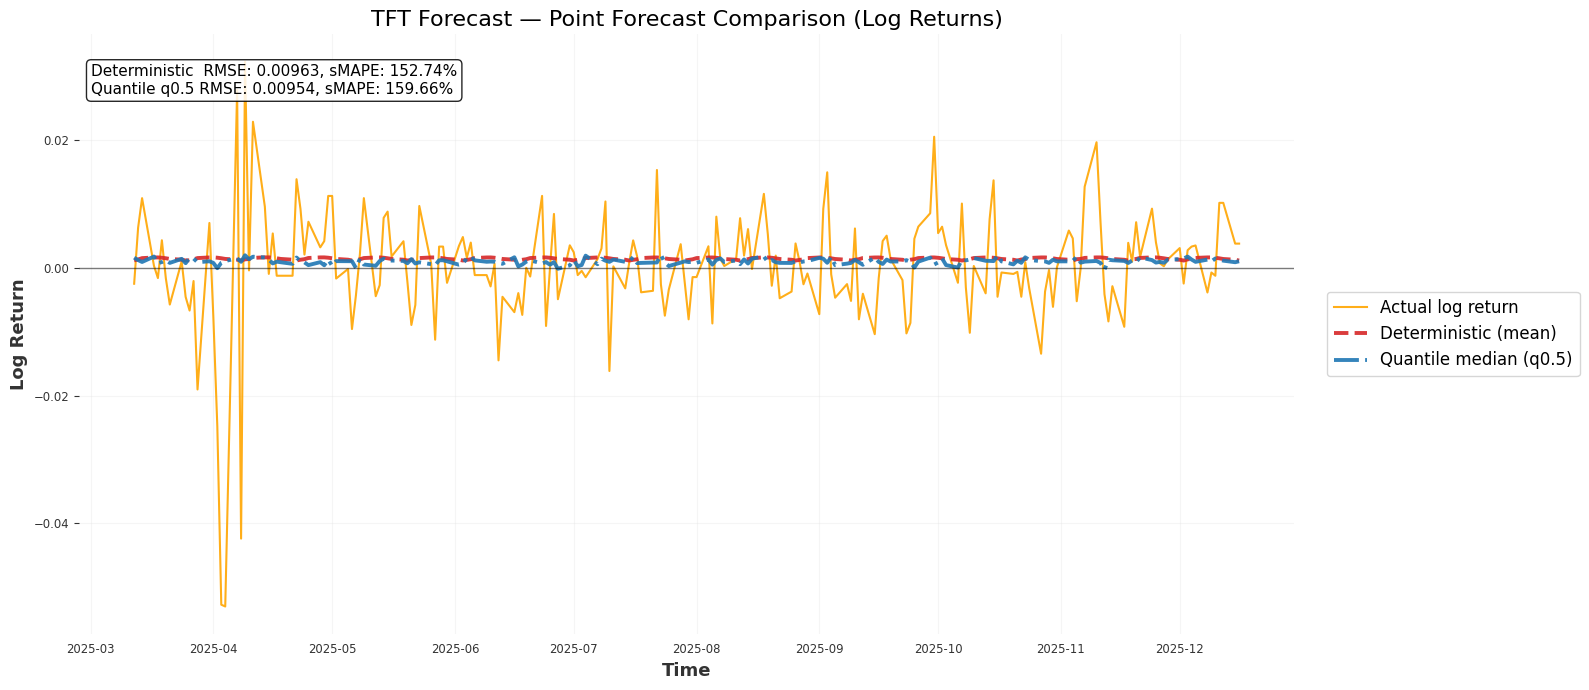

In [17]:
plt.figure(figsize=(16, 7))

# Actual
plt.plot(
    x, actual_y,
    color="orange",
    linewidth=1.5,
    alpha=0.9,
    label="Actual log return",
)

# Deterministic (mean)
plt.plot(
    x, det_y,
    color="tab:red",
    linestyle="--",
    linewidth=2.8,
    alpha=0.9,
    label="Deterministic (mean)",
)

# Quantile median
plt.plot(
    x, q05_y,
    color="tab:blue",
    linestyle="-.",
    linewidth=2.8,
    alpha=0.9,
    label="Quantile median (q0.5)",
)

plt.axhline(0, color="black", linewidth=1, alpha=0.5)

plt.title("TFT Forecast — Point Forecast Comparison (Log Returns)", fontsize=16)
plt.xlabel("Time", fontsize=13)
plt.ylabel("Log Return", fontsize=13)

# ⬇️ move legend OUTSIDE the plot
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=12,
    frameon=True,
)

plt.grid(alpha=0.3)
plt.tight_layout()



rmse_det = results["rmse"]
smape_det = results["smape"]

rmse_q = results["quantile"]["metrics"]["rmse"]
smape_q = results["quantile"]["metrics"]["smape"]

text = (
    f"Deterministic  RMSE: {rmse_det:.5f}, sMAPE: {smape_det:.2f}%\n"
    f"Quantile q0.5 RMSE: {rmse_q:.5f}, sMAPE: {smape_q:.2f}%"
)

plt.text(
    0.01, 0.95, text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.show()


/home/isc-den/software/mniconda3/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


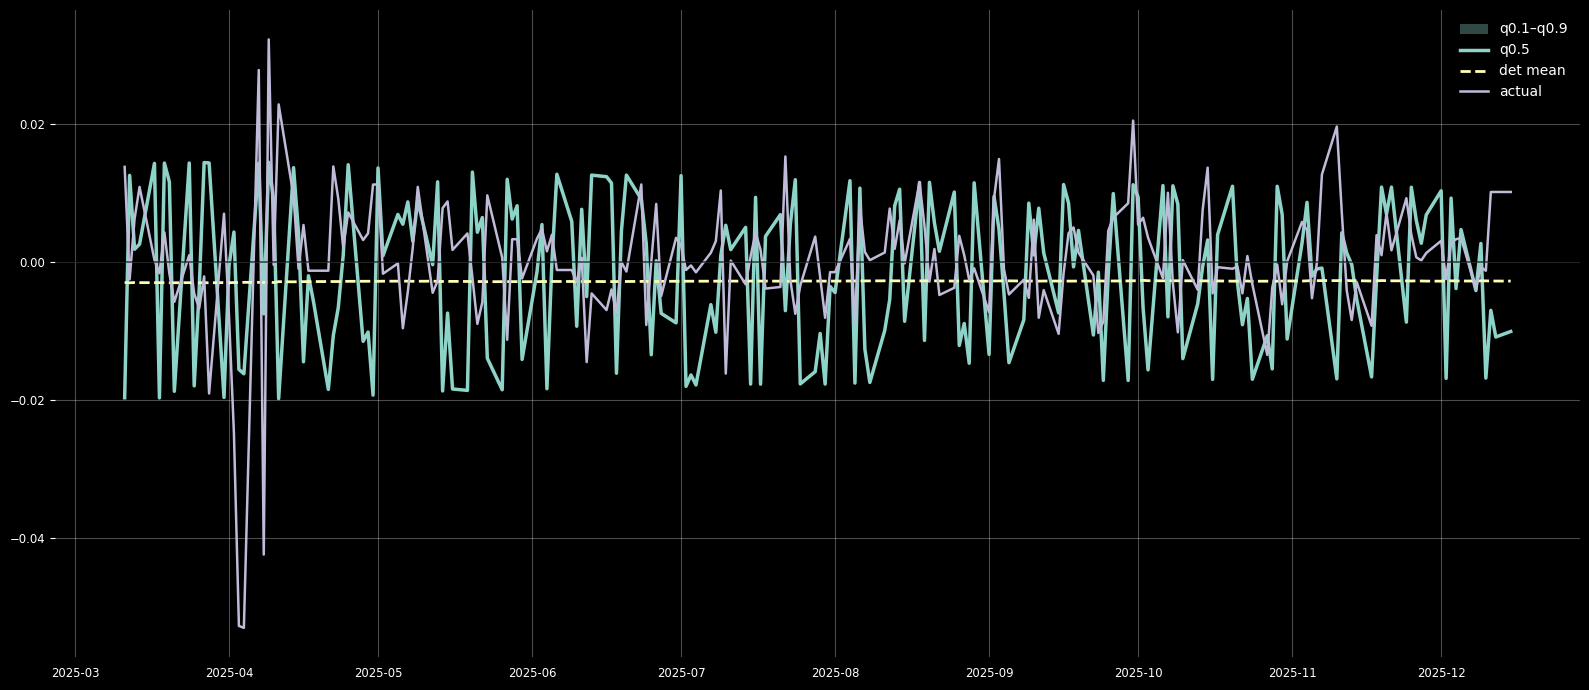

In [15]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

with open("results.pkl", "rb") as f:
    results = pickle.load(f)

actual = results["y_test"]
det = results["forecast"]
q = results["quantile"]["logret_forecasts"]

q01 = q["q01"].values().squeeze()
q05 = q["q05"].values().squeeze()
q09 = q["q09"].values().squeeze()
det_y = det.values().squeeze()
act_y = actual.values().squeeze()
x = actual.time_index

N = 300
x = x[-N:]
q01, q05, q09 = q01[-N:], q05[-N:], q09[-N:]
det_y, act_y = det_y[-N:], act_y[-N:]

plt.figure(figsize=(16, 7))
plt.fill_between(x, q01, q09, alpha=0.35, label="q0.1–q0.9")
plt.plot(x, q05, linewidth=2.5, label="q0.5")
plt.plot(x, det_y, "--", linewidth=2, label="det mean")
plt.plot(x, act_y, linewidth=1.8, label="actual")
plt.axhline(0, color="black", alpha=0.6)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


/home/isc-den/software/mniconda3/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


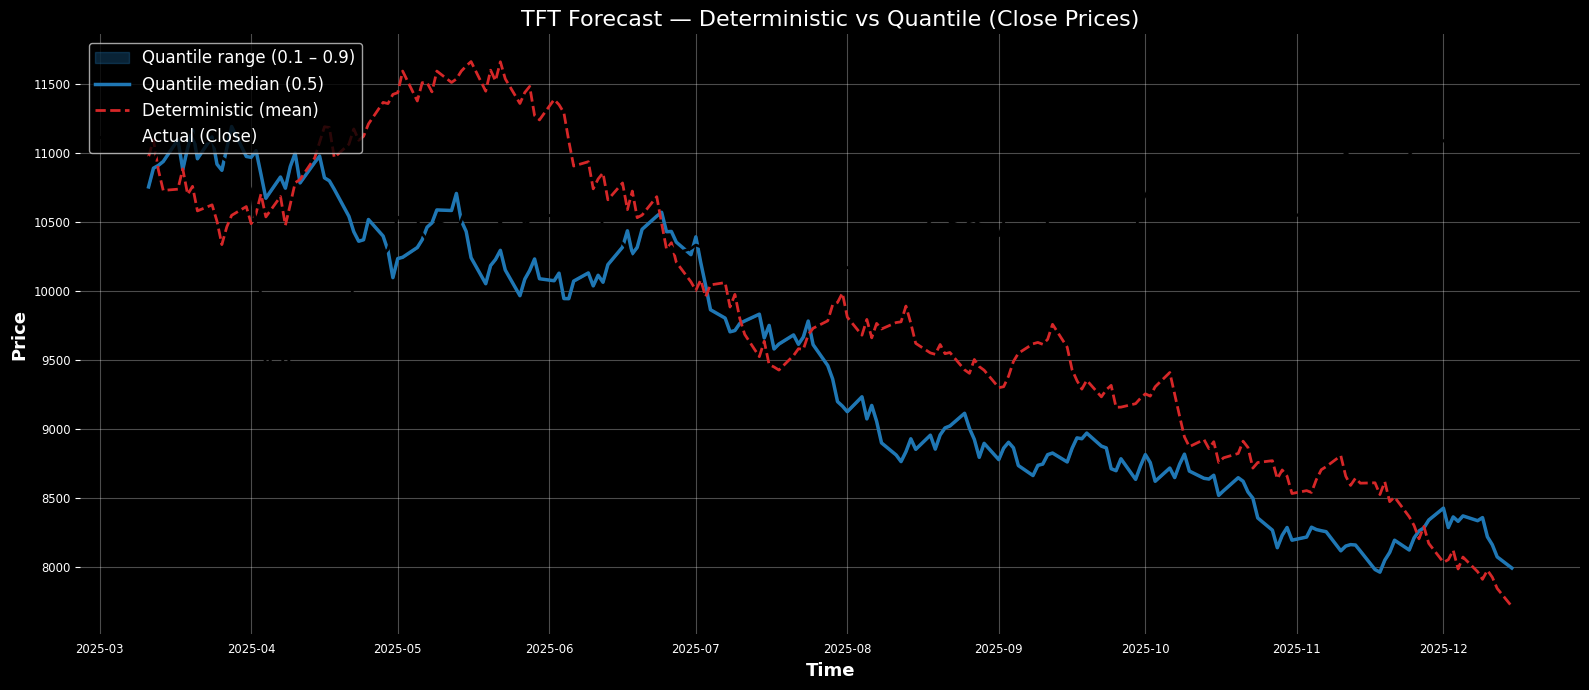

In [45]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Load results
# --------------------------------------------------
with open("results.pkl", "rb") as f:
    results = pickle.load(f)

# --------------------------------------------------
# Extract ACTUAL & deterministic prices
# --------------------------------------------------
actual_price = results["actual_price"]
det_price = results["forecast_price"]

# --------------------------------------------------
# Extract quantile LOG-RETURNS
# --------------------------------------------------
q = results["quantile"]["logret_forecasts"]
q01_lr = q["q01"]
q05_lr = q["q05"]
q09_lr = q["q09"]

# --------------------------------------------------
# Convert to numpy
# --------------------------------------------------
x = actual_price.time_index

actual_y = actual_price.values().squeeze()
det_y = det_price.values().squeeze()

q01_lr_y = q01_lr.values().squeeze()
q05_lr_y = q05_lr.values().squeeze()
q09_lr_y = q09_lr.values().squeeze()

# --------------------------------------------------
# Reconstruct quantile PRICES
# --------------------------------------------------
BASE_PRICE = actual_y[0]   # same base as used in your pipeline

def logret_to_price(logret, base_price):
    return base_price * np.exp(np.cumsum(logret))

q01_price = logret_to_price(q01_lr_y, BASE_PRICE)
q05_price = logret_to_price(q05_lr_y, BASE_PRICE)
q09_price = logret_to_price(q09_lr_y, BASE_PRICE)

# --------------------------------------------------
# Plot ONLY last N points
# --------------------------------------------------
N = 300

x = x[-N:]
actual_y = actual_y[-N:]
det_y = det_y[-N:]
q01_price = q01_price[-N:]
q05_price = q05_price[-N:]
q09_price = q09_price[-N:]

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(16, 7))

# 🔵 Quantile price range
plt.fill_between(
    x,
    q01_price,
    q09_price,
    color="tab:blue",
    alpha=0.30,
    label="Quantile range (0.1 – 0.9)",
    zorder=1,
)

# 🔷 Quantile median price
plt.plot(
    x,
    q05_price,
    color="tab:blue",
    linewidth=2.5,
    label="Quantile median (0.5)",
    zorder=2,
)

# 🔴 Deterministic forecast price
plt.plot(
    x,
    det_y,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label="Deterministic (mean)",
    zorder=3,
)

# ⚫ Actual Close price
plt.plot(
    x,
    actual_y,
    color="black",
    linewidth=2,
    label="Actual (Close)",
    zorder=4,
)

plt.title("TFT Forecast — Deterministic vs Quantile (Close Prices)", fontsize=16)
plt.xlabel("Time", fontsize=13)
plt.ylabel("Price", fontsize=13)

plt.legend(loc="upper left", fontsize=12, frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [46]:
feature_importances = results["y_train_val_sc"]


feature_importances.columns

Index(['log_return_morgen'], dtype='object')

/tmp/ipykernel_352878/3646318652.py:11: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/isc-den/software/mniconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


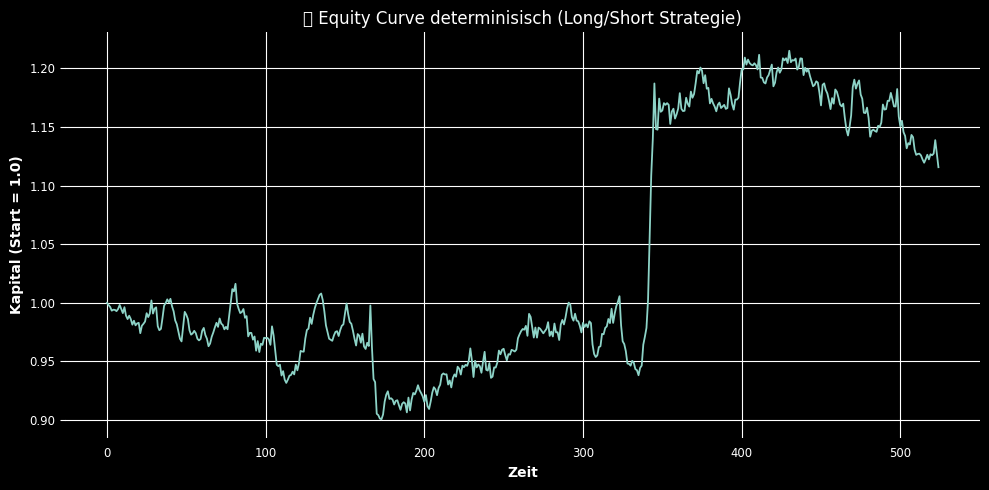

In [47]:
df = results['trading']
df.keys()
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["equity_curve"])
plt.title("📈 Equity Curve determinisisch (Long/Short Strategie)")
plt.xlabel("Zeit")
plt.ylabel("Kapital (Start = 1.0)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [48]:
df = results['trading_quantile']
df.keys()
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["equity_curve"])
plt.title("📈 Equity Curve Quantile (Long/Short Strategie)")
plt.xlabel("Zeit")
plt.ylabel("Kapital (Start = 1.0)")
plt.grid(True)
plt.tight_layout()
plt.show()

KeyError: 'trading_quantile'

In [ ]:
historical_forecasts = results["historical_actual_log_ret_quantile"]
# Korrektur: Wir extrahieren die Werte als NumPy Array mit .values()
forecast_values = historical_forecasts["log_return_morgen"].values()

# Das Resultat ist ein 2D-Array (Zeit x Komponenten/Features).
# Da Sie nur eine Komponente (log_return_morgen) haben, wählen Sie die erste Spalte (Index 0).
# Wir verwenden .flatten() oder wählen die Spalte [:, 0].
forecast_1d_array = forecast_values.flatten()

# Nun die deskriptiven Statistiken berechnen:
print(pd.Series(forecast_1d_array).sum())

In [ ]:
results.get("forecast_price_bt_quantile_01")


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def to_pd_series(x):
    if x is None:
        return None
    if hasattr(x, "pd_series"):
        try:
            return x.pd_series()
        except Exception:
            pass
    if hasattr(x, "to_series"):
        try:
            return x.to_series()
        except Exception:
            pass
    if hasattr(x, "to_dataframe"):
        try:
            df = x.to_dataframe()
            if isinstance(df, pd.DataFrame) and df.shape[1] >= 1:
                return df.iloc[:, 0]
        except Exception:
            pass
    if isinstance(x, pd.DataFrame):
        return x.iloc[:, 0]
    if isinstance(x, pd.Series):
        return x
    # fallback for numpy/iterable
    try:
        return pd.Series(np.asarray(x))
    except Exception:
        return None

def plot_quantile_band(
        actual,
        det_forecast=None,
        q01=None,
        q05=None,
        q09=None,
        title="Actual vs Deterministic vs Quantile (0.1/0.5/0.9)",
        figsize=(12, 6),
        colors=None,
):
    colors = colors or {
        "actual": "#222222",
        "det": "#1f77b4",
        "q05": "#ff7f0e",
        "band": "#ff7f0e",
    }

    s_actual = to_pd_series(actual)
    s_det = to_pd_series(det_forecast)
    s_q01 = to_pd_series(q01)
    s_q05 = to_pd_series(q05)
    s_q09 = to_pd_series(q09)

    parts = {}
    if s_actual is not None:
        parts["actual"] = s_actual
    if s_det is not None:
        parts["det"] = s_det
    if s_q01 is not None:
        parts["q01"] = s_q01
    if s_q05 is not None:
        parts["q05"] = s_q05
    if s_q09 is not None:
        parts["q09"] = s_q09

    if not parts:
        raise ValueError("Provide at least one series (actual, det_forecast or quantiles)")

    df = pd.concat(parts.values(), axis=1, keys=parts.keys()).sort_index()

    fig, ax = plt.subplots(figsize=figsize)

    if "q01" in df.columns and "q09" in df.columns:
        lower = df["q01"]
        upper = df["q09"]
        valid = ~(lower.isna() | upper.isna())
        ax.fill_between(
            df.index,
            lower,
            upper,
            where=valid,
            color=colors["band"],
            alpha=0.18,
            label="Quantile 0.1-0.9",
        )

    if "q05" in df.columns:
        ax.plot(df.index, df["q05"], color=colors["q05"], linestyle="--", label="Quantile 0.5 (median)")

    if "det" in df.columns:
        ax.plot(df.index, df["det"], color=colors["det"], label="Deterministic forecast", linewidth=1.5)

    if "actual" in df.columns:
        ax.plot(df.index, df["actual"], color=colors["actual"], label="Actual", linewidth=2)

    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
    return ax

# --- Example usage: adjust keys to match your `results` structure if needed ---
# Uses variables commonly present in this notebook:
plot_quantile_band(
    actual=results.get("y_test", results.get("y_test_series")),
    det_forecast=results.get("forecast"),
    q01=results.get("forecast_price_bt_quantile_01"),
    q05=results.get("forecast_price_bt_quantile_05"),
    q09=results.get("forecast_price_bt_quantile_09"),
    title="Quantile band vs Actual and Deterministic"
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Die TimeSeries-Objekte von Darts haben eine eingebaute Plot-Methode

# ----------------------------------------------------------------------
# 1. Sicherstellen, dass die Prognose als TimeSeries vorliegt
# ----------------------------------------------------------------------
# Abhängig davon, wie results gespeichert sind, müssen wir die TimeSeries extrahieren.
# Wir nehmen an, dass 'forecast_series' das Darts TimeSeries-Objekt der Prognose ist.
forecast_series = results["historical_forecasts"]["log_return_morgen"]
y_test = results["y_test"]
y_train_val = results["y_train_val"]
# ----------------------------------------------------------------------
# 2. Die Visualisierung der Prognose (Testbereich)
# ----------------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.title("Historische Prognosen vs. Tatsächliche Log-Returns (Test-Set)")

# Tatsächliche Werte (oft in Schwarz oder Dunkelgrau)
y_test.plot(label="Tatsächliche Log-Returns", color="darkblue")

# Prognostizierte Werte (oft in Rot oder Orange)
# Wir plotten die Vorhersage direkt gegen die tatsächlichen Testdaten.
forecast_series.plot(label="Historische Prognose (log_return_morgen)", color="red", linestyle="--")

plt.legend()
plt.grid(True)
plt.show()

# ----------------------------------------------------------------------
# 3. Optional: Gesamter Verlauf (Train + Test + Prognose)
# ----------------------------------------------------------------------

# Hinzufügen des Training-Sets, um den Gesamtkontext zu sehen
plt.figure(figsize=(16, 6))
plt.title("Gesamter Zeitverlauf: Training, Test und Prognose")

# Training-Set (grau)
y_train_val.plot(label="Trainingsdaten (Log-Returns)", color="lightgrey")

# Tatsächliche Werte im Test-Set (dunkelblau)
y_test.plot(label="Tatsächliche Testdaten", color="darkblue")

# Prognose (rot)
forecast_series.plot(label="Historische Prognose", color="red", linestyle="--")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Original-DataFrame
df = results["df_feat"].copy()


# Zeit-Parameter
test_size = results["data"].test_size if "data" in results else 200
val_size = results["data"].val_size if "data" in results else 100
total_len = len(df)

# Zeitsegmente berechnen
train_end = total_len - test_size - val_size
val_end = total_len - test_size

df["split"] = "train"
df.iloc[train_end:val_end, df.columns.get_loc("split")] = "val"
df.iloc[val_end:, df.columns.get_loc("split")] = "test"

colors = {"train": "lightgreen", "val": "red", "test": "lightblue"}

# === Plot 1: Close Preis mit Segmentfarben ===
plt.figure(figsize=(14, 5))
for split, color in colors.items():
    segment = df[df["split"] == split]
    plt.plot(segment.index, segment["close"], label=split, color=color)
plt.title("Effektiver Close-Preis mit Segmentierung")
plt.xlabel("Datum")
plt.ylabel("Preis")
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 2: Log-Returns mit Segmentfarben ===
plt.figure(figsize=(14, 5))
for split, color in colors.items():
    segment = df[df["split"] == split]
    plt.plot(segment.index, segment["log_return"], label=split, color=color)
plt.title("Log-Return mit Segmentierung")
plt.xlabel("Datum")
plt.ylabel("Log-Rendite")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
results["y_test"].plot(label="Actual Log-Return")
results["forecast"].plot(label="Forecast Log-Return")
plt.title("Log-Return Forecast vs Actual (Test Set)")
plt.xlabel("Datum")
plt.ylabel("Log-Rendite")
plt.legend()
plt.tight_layout()
plt.show()




In [ ]:
feature_importances = results["feature_importances"]
feature_importances.keys()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

fi = results["feature_importances"]

# --- Encoder ---
encoder_df = fi["encoder_importance"].T
encoder_df.columns = ["importance"]
encoder_df = encoder_df.sort_values("importance", ascending=True)

plt.figure(figsize=(8,6))
encoder_df.plot(kind="barh", legend=False)
plt.title("Encoder Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# --- Decoder ---
decoder_df = fi["decoder_importance"].T
decoder_df.columns = ["importance"]
decoder_df = decoder_df.sort_values("importance", ascending=True)

plt.figure(figsize=(6,4))
decoder_df.plot(kind="barh", legend=False, color="orange")
plt.title("Decoder Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# --- Static Covariates ---
static_df = fi["static_covariates_importance"]

if static_df is not None and not static_df.empty:
    static_df = static_df.T
    static_df.columns = ["importance"]
    static_df = static_df.sort_values("importance", ascending=True)

    plt.figure(figsize=(6,4))
    static_df.plot(kind="barh", legend=False, color="green")
    plt.title("Static Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("No static covariate importances to plot.")

